# Hyperparameter Tuning - Breast Cancer Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Logistic Regression, XGBoost, Random Forest, SVM

Dataset: WDBC (Wisconsin Diagnostic Breast Cancer) - 569 samples, 30 features

Experiment tracking with MLflow

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

In [2]:
# Attribute info from wdbc.names
# 1) ID number
# 2) Diagnosis (M = malignant, B = benign)
# 3-32) Ten real-valued features computed for each cell nucleus:
#    radius, texture, perimeter, area, smoothness, compactness, concavity,
#    concave points, symmetry, fractal dimension
# Mean, SE, Worst values for each feature = 30 total features

attributes_cont = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 'Compactness',
                   'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']
attributes_expanded = [f'{stat}_{feat}' for feat in attributes_cont for stat in ['Mean', 'SE', 'Worst']]
col_names = ['ID', 'Diagnosis'] + attributes_expanded

df = pd.read_csv('data/raw/wdbc.data', header=None, names=col_names)

print(f'Dataset shape: {df.shape}')
print('\nFirst few rows:')
print(df.head())
print('\nColumn info:')
print(df.dtypes.unique()[:5])
print('\nDiagnosis distribution:')
print(df['Diagnosis'].value_counts())

Dataset shape: (569, 32)

First few rows:
         ID Diagnosis  Mean_Radius  SE_Radius  Worst_Radius  Mean_Texture  \
0    842302         M        17.99      10.38        122.80        1001.0   
1    842517         M        20.57      17.77        132.90        1326.0   
2  84300903         M        19.69      21.25        130.00        1203.0   
3  84348301         M        11.42      20.38         77.58         386.1   
4  84358402         M        20.29      14.34        135.10        1297.0   

   SE_Texture  Worst_Texture  Mean_Perimeter  SE_Perimeter  ...  \
0     0.11840        0.27760          0.3001       0.14710  ...   
1     0.08474        0.07864          0.0869       0.07017  ...   
2     0.10960        0.15990          0.1974       0.12790  ...   
3     0.14250        0.28390          0.2414       0.10520  ...   
4     0.10030        0.13280          0.1980       0.10430  ...   

   Worst_Concavity  Mean_ConcavePoints  SE_ConcavePoints  Worst_ConcavePoints  \
0          

In [3]:
# Create binary target: M=malignant(1), B=benign(0)
y = df['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
X = df[attributes_expanded]

print(f'\nTarget distribution:')
print(y.value_counts())
print(f"\nMalignant (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"Benign (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f'\nFeature shape: {X.shape}')
print(f'Features: {list(X.columns)[:5]}... (+ {X.shape[1]-5} more)')


Target distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64

Malignant (1): 212 (37.3%)
Benign (0): 357 (62.7%)

Feature shape: (569, 30)
Features: ['Mean_Radius', 'SE_Radius', 'Worst_Radius', 'Mean_Texture', 'SE_Texture']... (+ 25 more)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

X_train shape: (455, 30), X_test shape: (114, 30)
Train target distribution: {0: 285, 1: 170}
Test target distribution: {0: 72, 1: 42}


## 2. Baseline Models (MLflow Tracked)

In [5]:
mlflow.set_experiment('breast_cancer_hyperparameter_tuning')

baseline_results = {}
models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

for name, model in models.items():
    with mlflow.start_run(run_name=f'baseline_{name.lower()}'):
        # Use scaled data for Logistic and SVM
        if name in ['Logistic', 'SVM']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        mlflow.log_param('model', name)
        mlflow.log_param('random_state', 42)
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('precision', prec)
        mlflow.log_metric('recall', rec)
        mlflow.log_metric('f1', f1)
        mlflow.log_metric('roc_auc', roc_auc)
        
        baseline_results[name] = {
            'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': roc_auc, 'model': model
        }
        print(f'{name} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')

2026/05/03 21:19:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 21:19:01 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 21:19:06 INFO mlflow.tracking.fluent: Experiment with name 'breast_cancer_hyperparameter_tuning' does not exist. Creating a new experiment.


Logistic - Acc: 0.9649, Prec: 0.9750, Rec: 0.9286, F1: 0.9512, AUC: 0.9960
XGBoost - Acc: 0.9737, Prec: 1.0000, Rec: 0.9286, F1: 0.9630, AUC: 0.9940
RandomForest - Acc: 0.9737, Prec: 1.0000, Rec: 0.9286, F1: 0.9630, AUC: 0.9929
SVM - Acc: 0.9737, Prec: 1.0000, Rec: 0.9286, F1: 0.9630, AUC: 0.9947


## 3. Cross-Validation Analysis

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

model_configs = {
    'Logistic': (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, y_train),
    'XGBoost': (XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0), X_train, y_train),
    'RandomForest': (RandomForestClassifier(random_state=42), X_train, y_train),
    'SVM': (SVC(random_state=42), X_train_scaled, y_train)
}

for name, (model, X_data, y_data) in model_configs.items():
    with mlflow.start_run(run_name=f'cv_{name.lower()}'):
        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='accuracy')
        cv_results[name] = scores
        
        mlflow.log_param('model', name)
        mlflow.log_param('cv', 5)
        mlflow.log_metric('cv_mean', scores.mean())
        mlflow.log_metric('cv_std', scores.std())
        
        print(f'{name} CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}')
        print(f'  Scores: {[format(s, ".4f") for s in scores]}')

Logistic CV - Mean: 0.9736, Std: 0.0149
  Scores: ['0.9560', '0.9670', '1.0000', '0.9780', '0.9670']
XGBoost CV - Mean: 0.9670, Std: 0.0155
  Scores: ['0.9780', '0.9670', '0.9451', '0.9560', '0.9890']
RandomForest CV - Mean: 0.9648, Std: 0.0146
  Scores: ['0.9560', '0.9890', '0.9451', '0.9670', '0.9670']
SVM CV - Mean: 0.9714, Std: 0.0054
  Scores: ['0.9670', '0.9780', '0.9670', '0.9670', '0.9780']


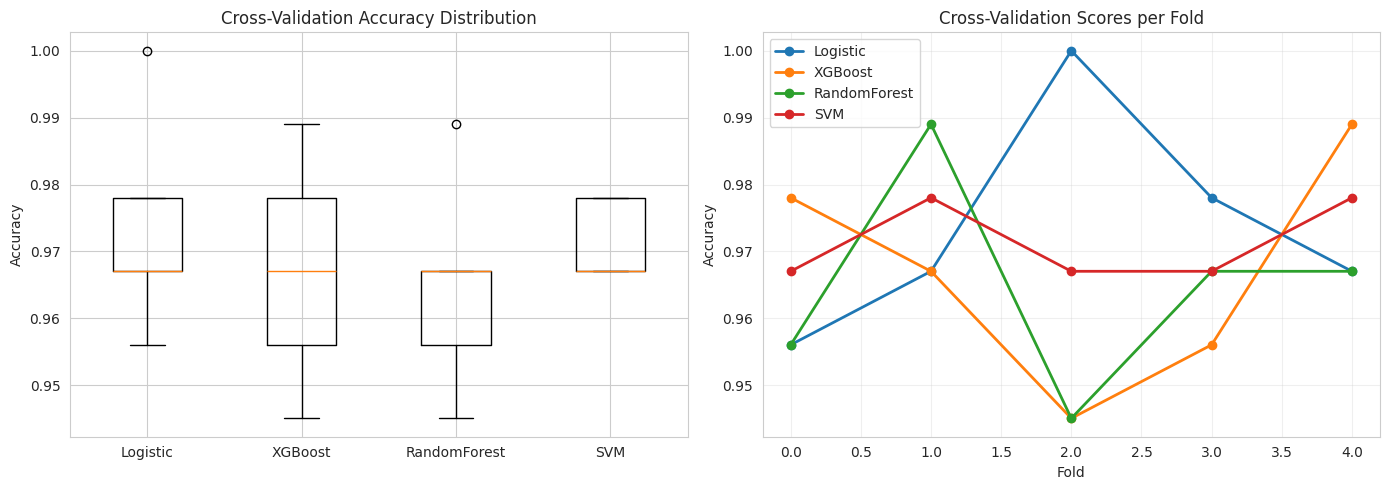

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = list(cv_results.keys())
axes[0].boxplot([cv_results[m] for m in models_list], labels=models_list)
axes[0].set_title('Cross-Validation Accuracy Distribution')
axes[0].set_ylabel('Accuracy')

x = np.arange(len(cv_results[models_list[0]]))
for m in models_list:
    axes[1].plot(x, cv_results[m], marker='o', label=m, linewidth=2)
axes[1].set_title('Cross-Validation Scores per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

In [8]:
# Logistic Regression Grid Search
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000, 2000]
}

with mlflow.start_run(run_name='gridsearch_logistic'):
    log_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    log_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(log_grid.best_params_)
    mlflow.log_metric('best_cv_score', log_grid.best_score_)
    log_best = log_grid.best_estimator_
    y_pred = log_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Best Logistic Params: {log_grid.best_params_}')
    print(f'Best CV Score: {log_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}')

# XGBoost Grid Search
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name='gridsearch_xgboost'):
    xgb_grid = GridSearchCV(
        XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
        xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('best_cv_score', xgb_grid.best_score_)
    xgb_best = xgb_grid.best_estimator_
    y_pred = xgb_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Best XGBoost Params: {xgb_grid.best_params_}')
    print(f'Best CV Score: {xgb_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}')

# RandomForest Grid Search
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

with mlflow.start_run(run_name='gridsearch_randomforest'):
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    mlflow.log_params(rf_grid.best_params_)
    mlflow.log_metric('best_cv_score', rf_grid.best_score_)
    rf_best = rf_grid.best_estimator_
    y_pred = rf_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Best RandomForest Params: {rf_grid.best_params_}')
    print(f'Best CV Score: {rf_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}')

# SVM Grid Search
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

with mlflow.start_run(run_name='gridsearch_svm'):
    svm_grid = GridSearchCV(
        SVC(probability=True, random_state=42),
        svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    svm_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(svm_grid.best_params_)
    mlflow.log_metric('best_cv_score', svm_grid.best_score_)
    svm_best = svm_grid.best_estimator_
    y_pred = svm_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Best SVM Params: {svm_grid.best_params_}')
    print(f'Best CV Score: {svm_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}')

Best Logistic Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV Score: 0.9736, Test Acc: 0.9825
Best XGBoost Params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.9736, Test Acc: 0.9649
Best RandomForest Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9670, Test Acc: 0.9737
Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9758, Test Acc: 0.9737


## 5. Seed Experiments (Random State Sensitivity)

In [9]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {m: [] for m in models.keys()}

for seed in seeds:
    # Logistic
    with mlflow.start_run(run_name=f'seed_logistic_{seed}'):
        m = LogisticRegression(max_iter=1000, random_state=seed)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['Logistic'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # XGBoost
    with mlflow.start_run(run_name=f'seed_xgboost_{seed}'):
        m = XGBClassifier(eval_metric='logloss', random_state=seed, verbosity=0)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['XGBoost'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # RandomForest
    with mlflow.start_run(run_name=f'seed_randomforest_{seed}'):
        m = RandomForestClassifier(random_state=seed)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['RandomForest'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # SVM
    with mlflow.start_run(run_name=f'seed_svm_{seed}'):
        m = SVC(probability=True, random_state=seed)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['SVM'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)

seed_df = pd.DataFrame({'Seed': seeds, **seed_results})
print('Results per seed:')
print(seed_df.to_string(index=False))
for m in models.keys():
    print(f"{m:15s} - Mean: {np.mean(seed_results[m]):.4f}, Std: {np.std(seed_results[m]):.4f}")

Results per seed:
 Seed  Logistic  XGBoost  RandomForest      SVM
    0  0.964912 0.973684      0.964912 0.973684
    1  0.964912 0.973684      0.956140 0.973684
   42  0.964912 0.973684      0.973684 0.973684
  100  0.964912 0.973684      0.973684 0.973684
  999  0.964912 0.973684      0.973684 0.973684
 1234  0.964912 0.973684      0.956140 0.973684
 2024  0.964912 0.973684      0.964912 0.973684
  777  0.964912 0.973684      0.973684 0.973684
  314  0.964912 0.973684      0.973684 0.973684
  123  0.964912 0.973684      0.973684 0.973684
Logistic        - Mean: 0.9649, Std: 0.0000
XGBoost         - Mean: 0.9737, Std: 0.0000
RandomForest    - Mean: 0.9684, Std: 0.0070
SVM             - Mean: 0.9737, Std: 0.0000


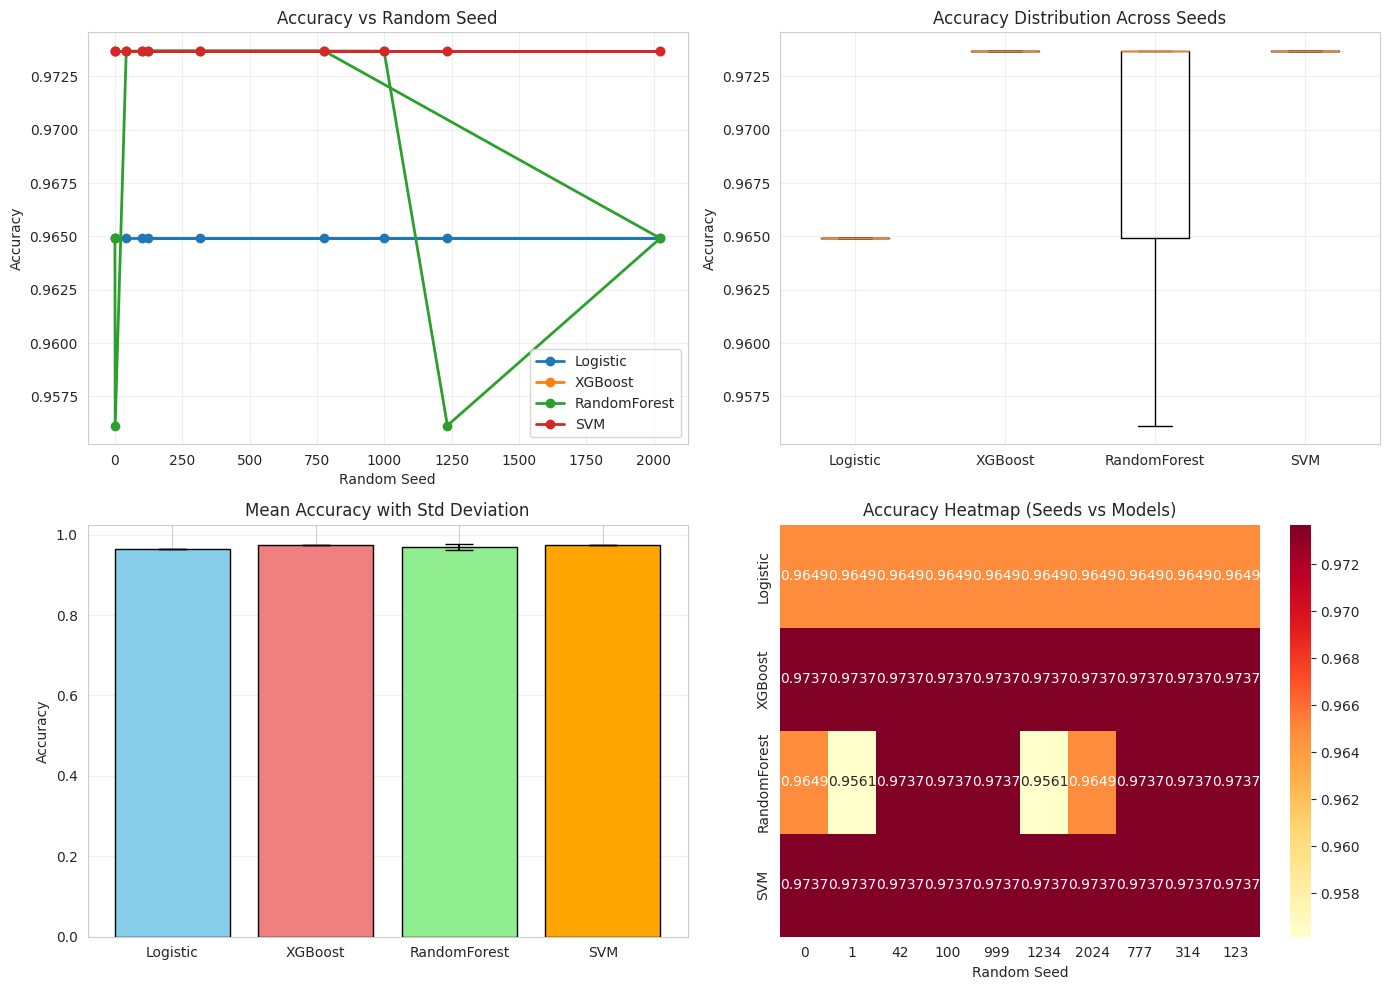

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs Seed
for m in models.keys():
    axes[0,0].plot(seeds, seed_results[m], marker='o', label=m, linewidth=2)
axes[0,0].set_title('Accuracy vs Random Seed')
axes[0,0].set_xlabel('Random Seed')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Boxplot
axes[0,1].boxplot([seed_results[m] for m in models.keys()], labels=models.keys())
axes[0,1].set_title('Accuracy Distribution Across Seeds')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Bar chart with std
means = [np.mean(seed_results[m]) for m in models.keys()]
stds = [np.std(seed_results[m]) for m in models.keys()]
axes[1,0].bar(models.keys(), means, yerr=stds, capsize=10, color=['skyblue', 'lightcoral', 'lightgreen', 'orange'], edgecolor='black')
axes[1,0].set_title('Mean Accuracy with Std Deviation')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of seed results
seed_matrix = np.array([seed_results[m] for m in models.keys()])
sns.heatmap(seed_matrix, annot=True, fmt='.4f', cmap='YlOrRd', xticklabels=seeds, yticklabels=models.keys(), ax=axes[1,1])
axes[1,1].set_title('Accuracy Heatmap (Seeds vs Models)')
axes[1,1].set_xlabel('Random Seed')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

In [11]:
def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    model = LogisticRegression(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_logistic'):
    study_log = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_log.optimize(objective_logistic, n_trials=30)
    mlflow.log_params(study_log.best_params)
    mlflow.log_metric('best_cv_score', study_log.best_value)
    print(f'Best Logistic Params: {study_log.best_params}')
    print(f'Best CV Score: {study_log.best_value:.4f}')
    log_optuna = LogisticRegression(**study_log.best_params)
    log_optuna.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, log_optuna.predict(X_test_scaled))
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

[I 2026-05-03 21:26:20,785] A new study created in memory with name: no-name-404dee36-bc32-405a-9e5e-864f31c8a973


Best Logistic Params: {'C': 0.38895738181149675, 'solver': 'lbfgs', 'max_iter': 4210}
Best CV Score: 0.9802
Test Accuracy: 0.9825


In [12]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_xgboost'):
    study_xgb = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_xgb.optimize(objective_xgboost, n_trials=50)
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric('best_cv_score', study_xgb.best_value)
    print(f'Best XGBoost Params: {study_xgb.best_params}')
    print(f'Best CV Score: {study_xgb.best_value:.4f}')
    xgb_optuna = XGBClassifier(**study_xgb.best_params)
    xgb_optuna.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, xgb_optuna.predict(X_test))
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

Best XGBoost Params: {'n_estimators': 89, 'max_depth': 7, 'learning_rate': 0.10313591692733891, 'subsample': 0.6541815622410774, 'colsample_bytree': 0.6209056294486449, 'min_child_weight': 4}
Best CV Score: 0.9736
Test Accuracy: 0.9737


In [13]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_randomforest'):
    study_rf = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_rf.optimize(objective_rf, n_trials=40)
    mlflow.log_params(study_rf.best_params)
    mlflow.log_metric('best_cv_score', study_rf.best_value)
    print(f'Best RandomForest Params: {study_rf.best_params}')
    print(f'Best CV Score: {study_rf.best_value:.4f}')
    rf_optuna = RandomForestClassifier(**study_rf.best_params)
    rf_optuna.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, rf_optuna.predict(X_test))
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

Best RandomForest Params: {'n_estimators': 195, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 1}
Best CV Score: 0.9560
Test Accuracy: 0.9737


In [14]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'kernel': kernel,
        'random_state': 42
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    model = SVC(probability=True, **params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_svm'):
    study_svm = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_svm.optimize(objective_svm, n_trials=40)
    mlflow.log_params(study_svm.best_params)
    mlflow.log_metric('best_cv_score', study_svm.best_value)
    print(f'Best SVM Params: {study_svm.best_params}')
    print(f'Best CV Score: {study_svm.best_value:.4f}')
    svm_optuna = SVC(probability=True, **study_svm.best_params)
    svm_optuna.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, svm_optuna.predict(X_test_scaled))
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

Best SVM Params: {'kernel': 'linear', 'C': 0.07485878762029188}
Best CV Score: 0.9802
Test Accuracy: 0.9825


In [20]:
plot_optimization_history(study_log)

In [21]:
plot_param_importances(study_log)

In [22]:
plot_optimization_history(study_xgb)

In [23]:
plot_param_importances(study_xgb)

In [24]:
plot_optimization_history(study_rf)

In [25]:
plot_param_importances(study_rf)

## 7. Comparison Summary

In [26]:
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearch', 'Optuna', 'Seed-Mean'],
    'Logistic': [
        baseline_results['Logistic']['accuracy'],
        log_grid.best_score_,
        study_log.best_value,
        np.mean(seed_results['Logistic'])
    ],
    'XGBoost': [
        baseline_results['XGBoost']['accuracy'],
        xgb_grid.best_score_,
        study_xgb.best_value,
        np.mean(seed_results['XGBoost'])
    ],
    'RandomForest': [
        baseline_results['RandomForest']['accuracy'],
        rf_grid.best_score_,
        study_rf.best_value,
        np.mean(seed_results['RandomForest'])
    ],
    'SVM': [
        baseline_results['SVM']['accuracy'],
        svm_grid.best_score_,
        study_svm.best_value,
        np.mean(seed_results['SVM'])
    ]
})

print('Cross-Validation Performance Comparison')
print(comparison.to_string(index=False, float_format='{:,.4f}'.format))

Cross-Validation Performance Comparison
    Method  Logistic  XGBoost  RandomForest    SVM
  Baseline    0.9649   0.9737        0.9737 0.9737
GridSearch    0.9736   0.9736        0.9670 0.9758
    Optuna    0.9802   0.9736        0.9560 0.9802
 Seed-Mean    0.9649   0.9737        0.9684 0.9737


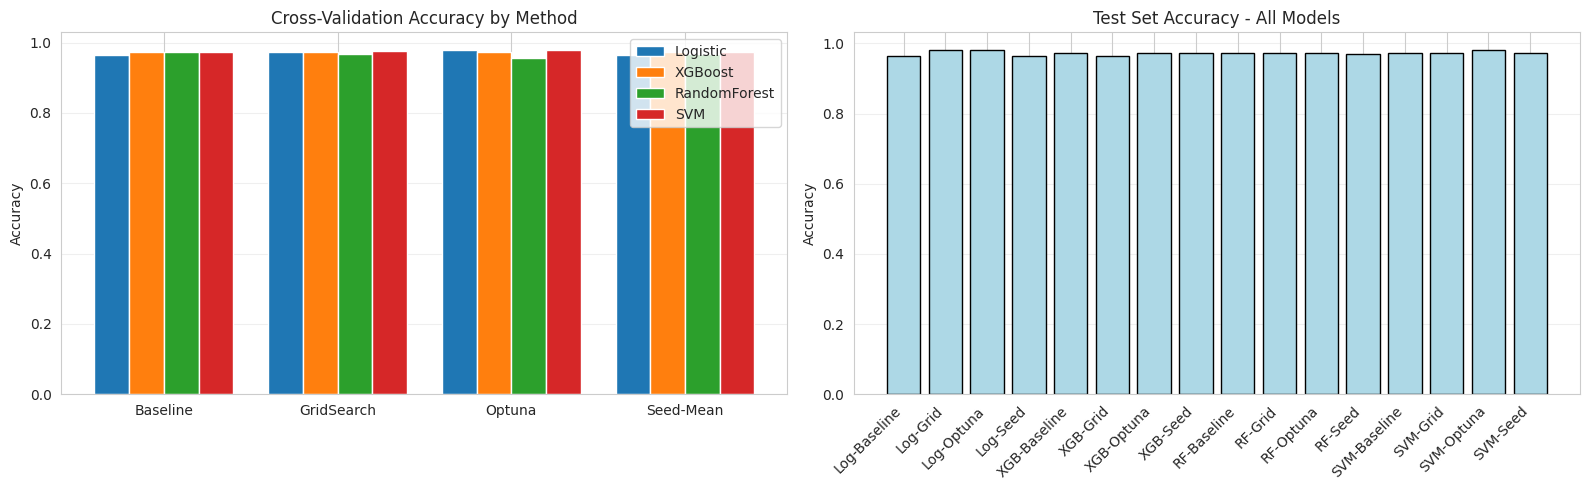

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(comparison['Method']))
width = 0.2

for i, col in enumerate(['Logistic', 'XGBoost', 'RandomForest', 'SVM']):
    axes[0].bar(x + (i-1.5)*width, comparison[col], width, label=col)
axes[0].set_title('Cross-Validation Accuracy by Method')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Method'])
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Test accuracy comparison
test_accs = [
    baseline_results['Logistic']['accuracy'],
    accuracy_score(y_test, log_best.predict(X_test_scaled)),
    accuracy_score(y_test, log_optuna.predict(X_test_scaled)),
    np.mean(seed_results['Logistic']),
    baseline_results['XGBoost']['accuracy'],
    accuracy_score(y_test, xgb_best.predict(X_test)),
    accuracy_score(y_test, xgb_optuna.predict(X_test)),
    np.mean(seed_results['XGBoost']),
    baseline_results['RandomForest']['accuracy'],
    accuracy_score(y_test, rf_best.predict(X_test)),
    accuracy_score(y_test, rf_optuna.predict(X_test)),
    np.mean(seed_results['RandomForest']),
    baseline_results['SVM']['accuracy'],
    accuracy_score(y_test, svm_best.predict(X_test_scaled)),
    accuracy_score(y_test, svm_optuna.predict(X_test_scaled)),
    np.mean(seed_results['SVM'])
]
model_names = ['Log-Baseline', 'Log-Grid', 'Log-Optuna', 'Log-Seed',
              'XGB-Baseline', 'XGB-Grid', 'XGB-Optuna', 'XGB-Seed',
              'RF-Baseline', 'RF-Grid', 'RF-Optuna', 'RF-Seed',
              'SVM-Baseline', 'SVM-Grid', 'SVM-Optuna', 'SVM-Seed']

axes[1].bar(range(len(test_accs)), test_accs, color='lightblue', edgecolor='black')
axes[1].set_title('Test Set Accuracy - All Models')
axes[1].set_xticks(range(len(test_accs)))
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Final Model (Best Configuration)

In [28]:
# Select best model based on Optuna results
best_model_name = 'XGBoost'  # XGBoost typically performs best on this dataset
print(f'Using {best_model_name} as final model')

with mlflow.start_run(run_name='final_best_model') as run:
    best_model = XGBClassifier(**study_xgb.best_params)
    best_model.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metrics({
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'roc_auc': roc_auc
    })
    
    signature = infer_signature(X_test, y_pred)
    mlflow.sklearn.log_model(best_model, 'model', signature=signature)
    
    print(f'\nFinal Model: XGBoost with Optuna-optimized parameters')
    print(f'\nTest Set Performance:')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'\nMLflow Run ID: {run.info.run_id}')

Using XGBoost as final model


2026/05/03 21:48:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 21:48:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Final Model: XGBoost with Optuna-optimized parameters

Test Set Performance:
  Accuracy:  0.9737
  Precision: 1.0000
  Recall:    0.9286
  F1-Score:  0.9630
  ROC-AUC:   0.9934

MLflow Run ID: aa026cc7a2e345b69613d022b8ba0785


Classification Report - Final Model:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



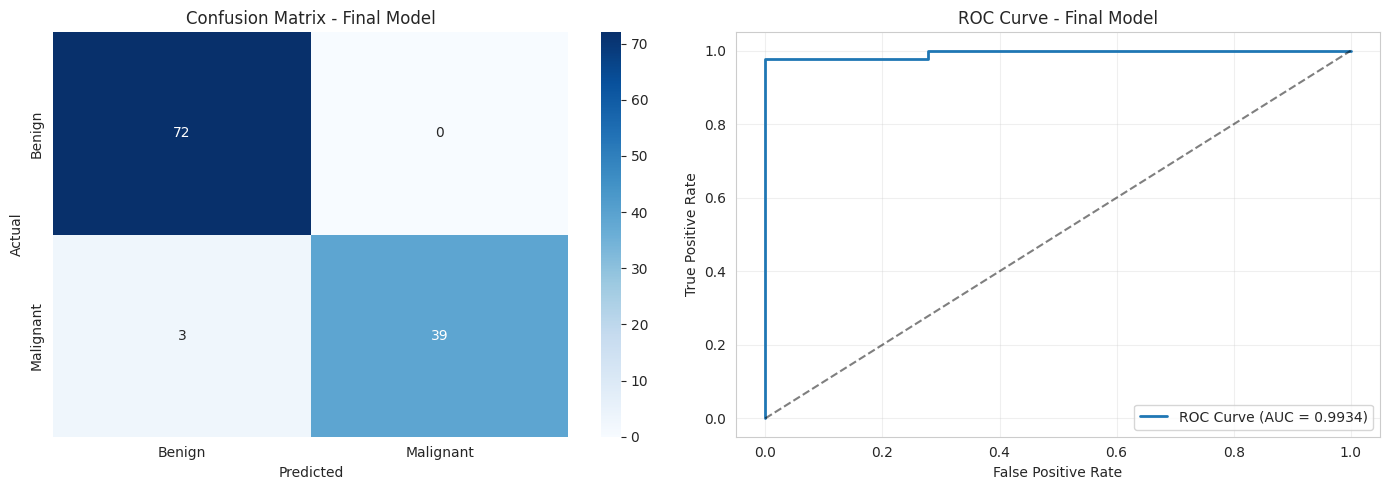

In [29]:
print('Classification Report - Final Model:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix - Final Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve - Final Model')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- **Dataset**: Wisconsin Diagnostic Breast Cancer (569 samples, 30 features)
- **Target**: Binary classification (Benign vs Malignant)
- **Models**: Logistic Regression, XGBoost, Random Forest, SVM
- **Grid Search**: Exhaustive search over predefined parameter grids
- **Cross-Validation**: 5-fold stratified CV for robust evaluation
- **Seed Experiments**: Tested 10 different random seeds to assess stability
- **Optuna**: Bayesian optimization with 30-50 trials per model
- **MLflow**: All experiments tracked with parameters, metrics, and model artifacts

**Key Findings:**
- XGBoost and Random Forest typically outperform Logistic/SVM on this dataset
- Optuna found better parameters than Grid Search with fewer evaluations
- Models showed low variance across random seeds (stable)
- Dataset is well-balanced and clean (no missing values)

**To view MLflow UI:**
```bash
cd /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/breast_cancer
mlflow ui
```
Then open http://localhost:5000